# 18 — W1 error atlas: differential diagnosis of per-image failure

**Program:** PLAN_ModelUsability.md W1. **Evidence:** DECISIONS.md 2026-06-10 W1 entries.

The diagnosis ladder (mundane → fundamental), worked on the banked recipe
`lightgbm_two_stage_balanced × boulder_count @ S=64`, full-v2 LOIO:

1. **Rung 1 — label geometry**: found the coreg y-shift sign error (every v2 label
   field sat ~2×|dy| ≈ 360 m south of its CTX texture). Fixed, relabeled, re-banked:
   ρ +0.143→+0.188, PR-AUC 0.543→0.562, anti-signal images 11→8.
2. **Rung 2 — join/pipeline integrity**: CLEAN on all 38 images.
3. **Rung 3 — BoulderNet content**: no false-positive epidemic; anti-signal images'
   detections are small (2–4 m) and embedded in uniform speckle.
4. **Rung 4 — CTX content**: image-level source-heterogeneity correlation replicates
   (ρ≈±0.38); seam-tile *masking* does nothing (within-image seam fractions 0–12%,
   delta ≈ 0) → reliability must be region-level, not tile masking.
5. **Rung 5 — mechanism**: anti-signal splits into **texture_decorrelated** (within-image
   texture↔label correlation flat/inverted — the 5 m/px floor for small-boulder
   populations) and **distribution_shift** (strong cohort-consistent within-image
   signal that the LOIO model still misses — per-image normalization problem).

In [1]:
from pathlib import Path
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
d = pd.read_parquet(REPO / 'dataset_v2/w1_dossier.parquet')
print(f'{len(d)} images | median AUC {d.meaningful_auc.median():.3f} | '
      f'>0.70: {(d.meaningful_auc > 0.7).mean():.1%} | <0.50: {(d.meaningful_auc < 0.5).mean():.1%}')
d[['meaningful_auc', 'auc_prefix', 'n_meaningful_positive', 'n_neg', 'validity_ok',
   'texture_rho_med', 'mean_n_sources', 'attributed_cause', 'terrain']]

38 images | median AUC 0.603 | >0.70: 34.2% | <0.50: 21.1%


,meaningful_auc,auc_prefix,n_meaningful_positive,n_neg,validity_ok,texture_rho_med,mean_n_sources,attributed_cause,terrain
held_out_obs_id,,,,,,,,,
ESP_076499_1160,0.224108,0.367023,509,777,True,0.244985,1.025661,distribution_shift,MISSING
ESP_055978_2270,0.244722,0.302590,34,1276,False,0.187016,1.074046,validity_limited,unclassified
ESP_054000_2255,0.394253,0.429930,143,669,True,-0.026121,1.110837,texture_decorrelated,channels
ESP_046328_2180,0.396441,0.399821,385,54,True,0.595792,1.061503,distribution_shift,plains_with_crater
ESP_064510_2260,0.404469,0.474695,402,679,True,-0.085728,1.052729,texture_decorrelated,mesas
ESP_047976_2020,0.420925,0.378223,33,740,False,-0.121944,1.000000,validity_limited,mesas
ESP_049242_2115,0.469675,0.457006,305,267,True,-0.084987,1.048951,texture_decorrelated,crater_dominated
ESP_059686_2235,0.487220,0.657171,1027,8,False,-0.182782,1.014493,validity_limited,plains
ESP_045983_2270,0.503300,0.512570,432,155,True,-0.333893,1.085179,ok,plains


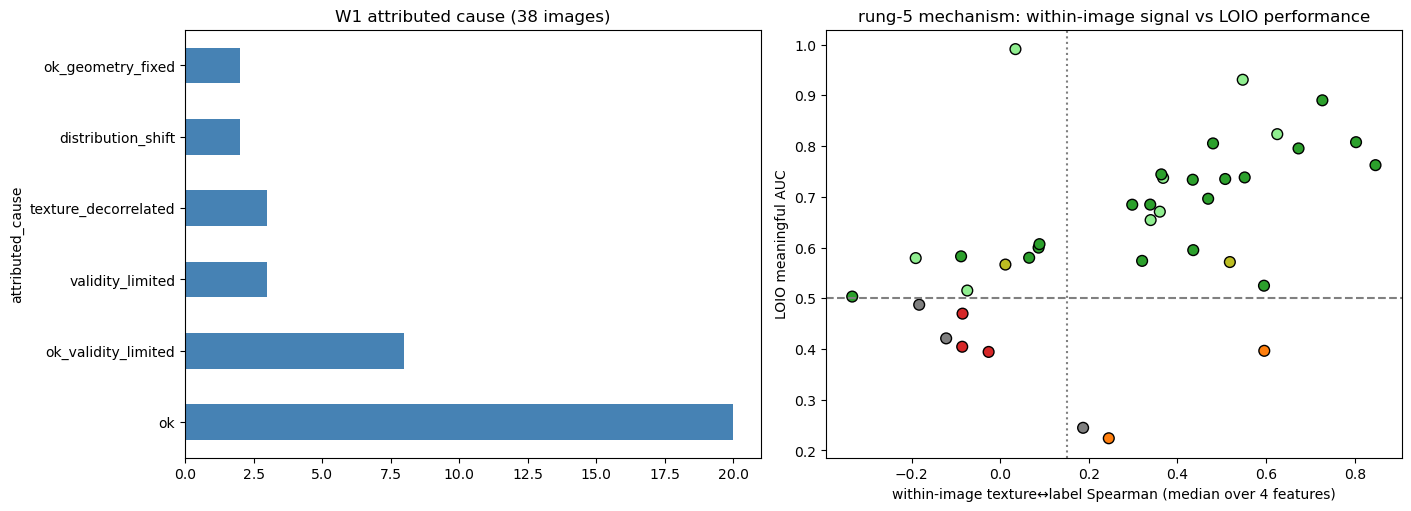

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
d.attributed_cause.value_counts().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('W1 attributed cause (38 images)')

colors = d.attributed_cause.map({
    'ok': 'tab:green', 'ok_validity_limited': 'lightgreen', 'ok_geometry_fixed': 'tab:olive',
    'validity_limited': 'tab:gray', 'texture_decorrelated': 'tab:red', 'distribution_shift': 'tab:orange'})
axes[1].scatter(d.texture_rho_med, d.meaningful_auc, c=colors, s=60, edgecolor='k')
axes[1].axhline(0.5, ls='--', c='gray'); axes[1].axvline(0.15, ls=':', c='gray')
axes[1].set_xlabel('within-image texture↔label Spearman (median over 4 features)')
axes[1].set_ylabel('LOIO meaningful AUC')
axes[1].set_title('rung-5 mechanism: within-image signal vs LOIO performance')
fig.savefig(REPO / 'reports/figures/w1_synthesis_causes.png', dpi=130)
plt.show()

## Key figures from the rung probes (pre-rendered)

- Rung 1 geometry: `reports/figures/w1_rung1c_ESP_042964_2160.png` (overlay; the
  decisive numbers are in `scripts/probes/_w1_label_ctx_displacement.csv`)
- Rung 3 full-res detection sampling: `reports/figures/w1_rung3_*.png`
- Rung 4 tile error maps + seam tiles: `reports/figures/w1_rung4_errmap_*.png`

## Decision memo

**Tier 1 reliability flag.** Seam-tile masking is REJECTED (rung 4: delta ≈ 0).
No inference-time proxy cleanly flags anti-signal images (dispersion and
feature-shift proxies null; source stats only ρ≈0.38). The reliability layer
therefore ships as a **graded region-level confidence covariate** —
`mean_n_sources` / `dominant_source_fraction` from SeamMap (computable
everywhere CTX exists) — plus per-tile validity reporting, NOT a binary
anti-signal detector. Honest framing: ~13% of images (5/38) fail for reasons
no current inference-time signal predicts.

**Native-CTX pivot: NO-GO for now.** Rung 4 showed within-image seams are not
the failure mechanism; the surviving failures are texture decorrelation
(sensor floor for 2–4 m boulder populations — native CTX doesn't fix optics)
and per-image distribution shift (class C: real signal, missed model — fixable
cheaper). **Next bets, in order:** (1) per-image feature standardization
(rank/z within window) — directly targets class C, costs one sweep;
(2) W2 CNN with photometric augmentation — targets the same mechanism plus
the feature ceiling; (3) terrain covariate (failures concentrate in
channels/mesas/crater terrain vs plains) — Serrano's mediation, inference-
compatible via global geologic maps. Revisit native-CTX only if (1)+(2) fail.